<a href="https://colab.research.google.com/github/malick08012/Web-Scraping-Countries-of-the-World/blob/main/Web_Scraping_Countries_of_the_World.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Required Libraries

In [2]:
pip install requests beautifulsoup4 pandas

Web Scrape

In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

base_url = 'https://scrapethissite.com/pages/simple/'
headers = {'User-Agent': 'Mozilla/5.0'}
country_data = []

# Start with the first page
response = requests.get(base_url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')

# Function to parse all country blocks from the page
def parse_page(soup):
    countries = soup.find_all('div', class_='country')
    for country in countries:
        name = country.find('h3', class_='country-name').text.strip()
        capital = country.find('span', class_='country-capital').text.strip()
        population = country.find('span', class_='country-population').text.strip()
        area = country.find('span', class_='country-area').text.strip()

        country_data.append({
            'Name': name,
            'Capital': capital,
            'Population': int(population.replace(',', '')),
            'Area (km²)': float(area.replace(',', ''))
        })

# Parse first page
parse_page(soup)

# Check for additional pages (pagination)
pagination = soup.select('ul.pagination li a')

for page in pagination:
    link = page.get('href')
    if link and 'page=' in link:
        full_url = 'https://scrapethissite.com' + link
        response = requests.get(full_url, headers=headers)
        soup = BeautifulSoup(response.text, 'html.parser')
        parse_page(soup)

No Panigation Required For This Website

Making a CSV file

In [4]:
# Save to CSV
df = pd.DataFrame(country_data)
df.to_csv('countries_data.csv', index=False)

print("Data scraped and saved to 'countries_data.csv'")

Data scraped and saved to 'countries_data.csv'


Data Cleaning And Preprocessing

First Load CSV File

In [5]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load the CSV file
df = pd.read_csv('countries_data.csv')

Handle Missing Value

In [6]:
# Step 1: Handle missing data
print("Missing values in each column:\n", df.isnull().sum())

# If there are missing values, we can drop rows or fill them
# df.dropna(inplace=True)  # Uncomment to drop rows with missing values
# Or you can fill missing data
# df.fillna({'Population': df['Population'].mean(), 'Area (km²)': df['Area (km²)'].mean()}, inplace=True)


Missing values in each column:
 Name          0
Capital       8
Population    0
Area (km²)    0
dtype: int64


Fill Missing Value Of Capital With "UNKNOWN"

In [7]:
# Fill missing values in the 'Capital' column with 'Unknown'
df['Capital'].fillna('Unknown', inplace=True)

# Check to ensure the missing values are handled
print("\nMissing values after filling:\n", df.isnull().sum())



Missing values after filling:
 Name          0
Capital       0
Population    0
Area (km²)    0
dtype: int64


<ipython-input-7-0e7204d906a2>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Capital'].fillna('Unknown', inplace=True)


Detect And Remove Outliers

In [8]:
# Step 2: Detect and Remove Outliers (Using IQR method)
Q1 = df[['Population', 'Area (km²)']].quantile(0.25)
Q3 = df[['Population', 'Area (km²)']].quantile(0.75)
IQR = Q3 - Q1

# Filter data to remove outliers
df_no_outliers = df[~((df[['Population', 'Area (km²)']] < (Q1 - 1.5 * IQR)) | (df[['Population', 'Area (km²)']] > (Q3 + 1.5 * IQR))).any(axis=1)]

Normalize Numerical Data, Display And Saved Cleaned Data

In [9]:
# Step 3: Normalize numerical data (Population, Area)
scaler = MinMaxScaler()
df_no_outliers[['Population', 'Area (km²)']] = scaler.fit_transform(df_no_outliers[['Population', 'Area (km²)']])

# Display cleaned data
print("\nCleaned data (first 5 rows):")
print(df_no_outliers.head())

# Save the cleaned data
df_no_outliers.to_csv('cleaned_countries_data.csv', index=False)



Cleaned data (first 5 rows):
                   Name           Capital  Population  Area (km²)
0               Andorra  Andorra la Vella    0.002515    0.000513
1  United Arab Emirates         Abu Dhabi    0.148976    0.090872
2           Afghanistan             Kabul    0.871929    0.709939
3   Antigua and Barbuda        St. John's    0.002598    0.000486
4              Anguilla        The Valley    0.000397    0.000112


<ipython-input-9-6724b93d1eea>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers[['Population', 'Area (km²)']] = scaler.fit_transform(df_no_outliers[['Population', 'Area (km²)']])


Exploratory Data Analysis (EDA)

Import Libraries

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Load Clean Data Set

In [10]:
df = pd.read_csv('cleaned_countries_data.csv')


Summary Statistics

In [11]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
       Population  Area (km²)
count  200.000000  200.000000
mean     0.162416    0.124767
std      0.230878    0.206065
min      0.000000    0.000000
25%      0.002758    0.000521
50%      0.050799    0.028327
75%      0.224885    0.135260
max      1.000000    1.000000


Visualizations

Text(0, 0.5, 'Frequency')

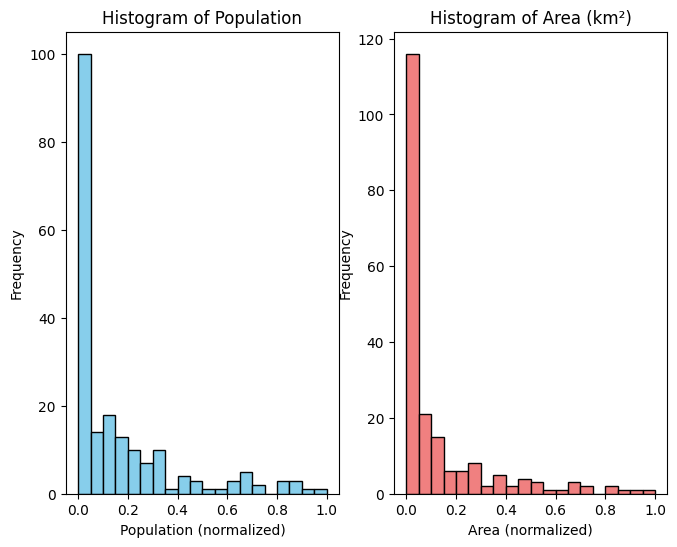

In [16]:
# Histogram for Population and Area
plt.figure(figsize=(12, 6))

# Histogram of Population
plt.subplot(1, 3, 1)
plt.hist(df['Population'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Population')
plt.xlabel('Population (normalized)')
plt.ylabel('Frequency')

# Histogram of Area
plt.subplot(1, 3, 2)
plt.hist(df['Area (km²)'], bins=20, color='lightcoral', edgecolor='black')
plt.title('Histogram of Area (km²)')
plt.xlabel('Area (normalized)')
plt.ylabel('Frequency')

Scatter Plot between Population and Area

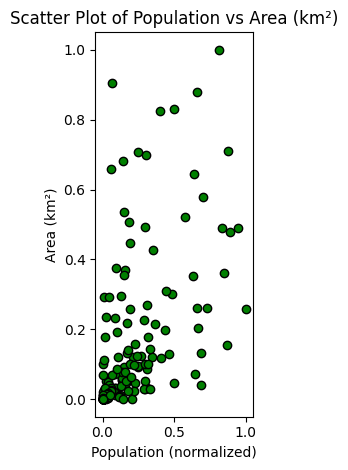

In [17]:
plt.subplot(1, 3, 3)
plt.scatter(df['Population'], df['Area (km²)'], color='green', edgecolor='black')
plt.title('Scatter Plot of Population vs Area (km²)')
plt.xlabel('Population (normalized)')
plt.ylabel('Area (km²)')

plt.tight_layout()
plt.show()

Boxplot for Population and Area

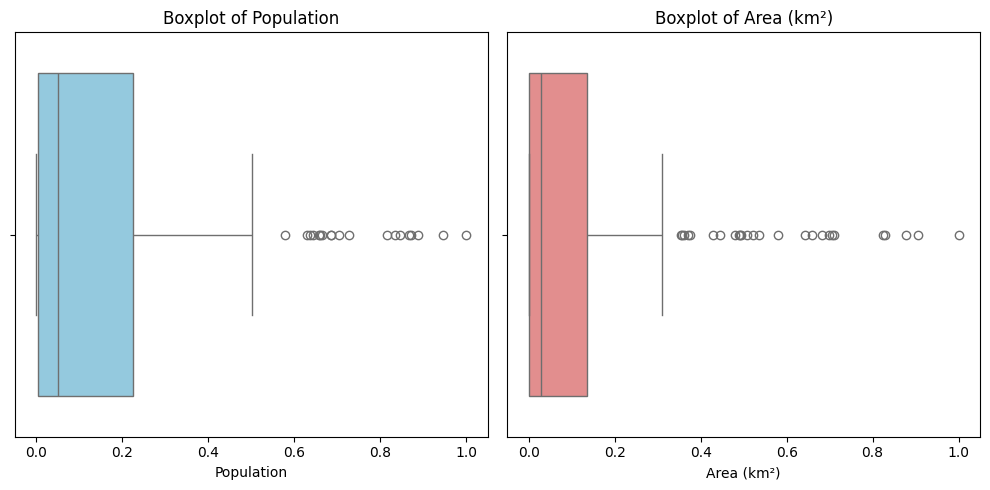

In [18]:
plt.figure(figsize=(10, 5))

# Boxplot for Population
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Population', color='skyblue')
plt.title('Boxplot of Population')

# Boxplot for Area
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Area (km²)', color='lightcoral')
plt.title('Boxplot of Area (km²)')

plt.tight_layout()
plt.show()


Correlation Matrix


Correlation Matrix:
            Population  Area (km²)
Population    1.000000    0.596431
Area (km²)    0.596431    1.000000


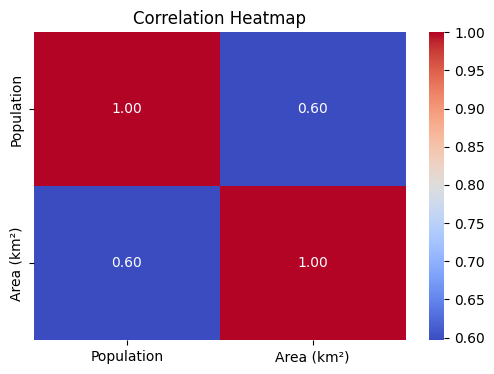

In [19]:
correlation_matrix = df[['Population', 'Area (km²)']].corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)

# Heatmap of the correlation matrix
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

EDA Report

EDA Summary Report: Countries Dataset
1. Data Overview:

> Population and Area (km²) are normalized (values
  range from 0 to 1).

> Data includes 200 countries.

2. Summary Statistics:

> Both features are right-skewed with many countries
  having small values and a few large outliers.

> Mean Population: 0.162

> Mean Area: 0.125

> Outliers: Present in both population and area (e.g.,
  large countries like Russia, China).

3. Visual Insights:

> Histograms: Most values cluster toward the lower
  end, confirming skewness.

> Scatter Plot: Shows a weak positive correlation —
  larger countries tend to have higher populations, but not consistently.

> Boxplots: Highlight the presence of high-end     outliers.

4. Correlation:

> Correlation coefficient (r): ~0.35
  Indicates a weak to moderate positive relationship between population and area.

5. Key Takeaways:

> Most countries are small in both area and population.

> A few countries dominate the top end of the scale.

> Population size is not strongly tied to land area.